# motif_generator 使用说明：输入 w,h 生成 motif 类型

这个 notebook 面向第一次使用的人。你只需要知道一个目标：

```text
输入 motif box 的 w,h
  -> 生成 motif 类型
  -> 保存成 CSV
  -> 后续交给最短延迟实验脚本使用
```

每个关键代码单元都尽量自包含：包含 imports、项目路径、输入参数和输出路径。

## 0. 基本概念

### w,h 是什么？

当前代码里的 `w` 是 motif box 的总宽度，包含最后一列 target boundary。

```text
可规划列数 = w - 1
h = y 方向相位高度
```

例如 `w=4,h=3` 表示 box 有 4 列 3 行，但只有前 3 列可以放 outgoing link，其实就是，最后一列没有右邻居的

### A/B/C/D/- 是什么？

```text
A = (dp=1, dy=0)   右侧同相位
B = (dp=1, dy=-1)  右侧下相位
C = (dp=1, dy=1)   右侧上相位
D = (dp=2, dy=0)   跨一个轨道面
- = 该 source 不放右邻居
```

约束是：每个节点最多 1 个右邻居，最多 1 个左邻居。

## 1. 环境检查

先运行这个单元，确认 Python 能找到项目里的 `src.motif_generator`。

In [1]:
import sys
from pathlib import Path

GENERIC_ROOT = Path(r"E:\paper11\generic")
if str(GENERIC_ROOT) not in sys.path:
    sys.path.insert(0, str(GENERIC_ROOT))

from src.motif_generator.module.exact_box import enumerate_maximal_exact_box
from src.motif_generator.module.library import canonical_primitive_representatives

print("GENERIC_ROOT =", GENERIC_ROOT)
print("motif_generator import OK")

GENERIC_ROOT = E:\paper11\generic
motif_generator import OK


## 2. 输入 w,h，查看 maximal 和 primitive 数量

这一步回答：固定 `w,h` 的 box 里，理论上能枚举多少 motif。

`maximal_count`：固定 box 内所有极大 motif 数量。  
`primitive_count`：去掉能由更小周期重复得到的 motif 后的数量。

这一步还没有做平移/图等价去重。

In [2]:
import sys
from pathlib import Path

GENERIC_ROOT = Path(r"E:\paper11\generic")
if str(GENERIC_ROOT) not in sys.path:
    sys.path.insert(0, str(GENERIC_ROOT))

from src.motif_generator.module.exact_box import count_maximal_exact_box, enumerate_primitive_exact_box

W = 4
H = 3

maximal_count = count_maximal_exact_box(W, H)
primitive = enumerate_primitive_exact_box(W, H)

print(f"w={W}, h={H}")
print("maximal_count =", maximal_count)
print("primitive_count =", len(primitive))

w=4, h=3
maximal_count = 1156
primitive_count = 1148


## 3. 实验真正使用的 canonical motif library

我们实验使用的 motif library 是：

```text
primitive_exact_box(w,h)
  -> 把 motif 平铺到一个小 torus 上
  -> 对全局 x/y 平移做 canonical key
  -> 平移/图等价的 motif 只保留一个代表
```

正式函数是：

```python
canonical_primitive_representatives(w, h)
```

对 `w=4,h=3`，应该得到 `706` 个 canonical motif。

In [3]:
import sys
from pathlib import Path

GENERIC_ROOT = Path(r"E:\paper11\generic")
if str(GENERIC_ROOT) not in sys.path:
    sys.path.insert(0, str(GENERIC_ROOT))

from src.motif_generator.module.library import canonical_primitive_representatives, motif_matrix_support_label
from src.motif_generator.module.exact_box import pretty_motif, motif_edges_as_user_ids

W = 4
H = 3
ROW_PITCH = 36

motifs, primitive_matrix_count = canonical_primitive_representatives(W, H)

print(f"w={W}, h={H}")
print("primitive_matrix_count =", primitive_matrix_count)
print("canonical_count =", len(motifs))
print()
print("前 5 个 motif：")
for idx, motif in enumerate(motifs[:5], start=1):
    print(f"#{idx:03d}", pretty_motif(motif))
    print("  support:", motif_matrix_support_label(motif))
    print("  edges:", ", ".join(motif_edges_as_user_ids(motif, row_pitch=ROW_PITCH)))

w=4, h=3
primitive_matrix_count = 1148
canonical_count = 706

前 5 个 motif：
#001 -BB | -BB | AAA
  support: [(0,1,B), (0,2,B), (1,1,B), (1,2,B), (2,0,A), (2,1,A), (2,2,A)]
  edges: 2-37, 3-38, 38-73, 39-74, 73-109, 74-110, 75-111
#002 -BB | -BB | ACB
  support: [(0,1,B), (0,2,B), (1,1,B), (1,2,B), (2,0,A), (2,1,C), (2,2,B)]
  edges: 2-37, 3-38, 38-73, 39-74, 73-109, 74-111, 75-110
#003 -BB | -BB | CBA
  support: [(0,1,B), (0,2,B), (1,1,B), (1,2,B), (2,0,C), (2,1,B), (2,2,A)]
  edges: 2-37, 3-38, 38-73, 39-74, 73-110, 74-109, 75-111
#004 -BB | AAA | AAA
  support: [(0,1,B), (0,2,B), (1,0,A), (1,1,A), (1,2,A), (2,0,A), (2,1,A), (2,2,A)]
  edges: 2-37, 3-38, 37-73, 38-74, 39-75, 73-109, 74-110, 75-111
#005 -BB | AAA | ACB
  support: [(0,1,B), (0,2,B), (1,0,A), (1,1,A), (1,2,A), (2,0,A), (2,1,C), (2,2,B)]
  edges: 2-37, 3-38, 37-73, 38-74, 39-75, 73-109, 74-111, 75-110


## 4. 保存成 CSV

后续最短延迟批处理脚本需要一个 CSV。最少需要字段：

```text
motif_id
motif
```

这里会额外保存 `w,h,edge_count,support,edges` 等字段，方便人工检查。

In [ ]:
import sys
from pathlib import Path

GENERIC_ROOT = Path(r"E:\paper11\generic")
if str(GENERIC_ROOT) not in sys.path:
    sys.path.insert(0, str(GENERIC_ROOT))

from src.motif_generator.module.library import write_canonical_motif_library_csv

W = 4
H = 3
OUT_DIR = Path(r"E:\paper11\data\linshi\motif_w4h3_canonical_from_notebook")
CSV_PATH = OUT_DIR / f"canonical_w{W}_h{H}.csv"

meta = write_canonical_motif_library_csv(CSV_PATH, w=W, h=H, row_pitch=36)

print("CSV written:", CSV_PATH)
print("canonical_count:", meta["canonical_count"])
print("summary json:", OUT_DIR / f"canonical_w{W}_h{H}_summary.json")

## 5. 检查 CSV

运行这个单元可以确认生成了多少 motif，以及前几行长什么样。

In [ ]:
import csv
from pathlib import Path

CSV_PATH = Path(r"E:\paper11\data\linshi\motif_w4h3_canonical_from_notebook\canonical_w4_h3.csv")

with CSV_PATH.open("r", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))

print("CSV_PATH =", CSV_PATH)
print("motif count =", len(rows))
for row in rows[:5]:
    print(f"motif_id={row['motif_id']}  motif={row['motif']}  edge_count={row['edge_count']}")
    print("  support:", row["support"])
    print("  edges:", row["edges"])

## 6. 命令行方式生成 library

如果不想打开 notebook，可以直接在 PowerShell 中运行：

```powershell
& 'C:\ProgramData\miniconda3\envs\paper11\python.exe' -u 'E:\paper11\generic\src\motif_generator\examples\generate_canonical_motif_library.py' --w 4 --h 3 --out-dir 'E:\paper11\data\linshi\motif_w4h3_canonical_from_src'
```

In [ ]:
import subprocess
from pathlib import Path

PYTHON = Path(r"C:\ProgramData\miniconda3\envs\paper11\python.exe")
SCRIPT = Path(r"E:\paper11\generic\src\motif_generator\examples\generate_canonical_motif_library.py")
OUT_DIR = Path(r"E:\paper11\data\linshi\motif_w4h3_canonical_from_subprocess")

cmd = [str(PYTHON), "-u", str(SCRIPT), "--w", "4", "--h", "3", "--out-dir", str(OUT_DIR)]
print("running:")
print(" ".join(cmd))
result = subprocess.run(cmd, text=True, capture_output=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit(result.returncode)

## 7. 手写一个 motif：support 表示法

推荐的手写格式是：

```python
motif = {
    "w": 3,
    "h": 3,
    "support": [
        (0, 0, "D"),
        (0, 1, "B"),
        (0, 2, "D"),
        (1, 2, "B"),
    ],
}
```

下面用 `motif_000056 = DBD | --B` 做例子。

In [4]:
import sys
from pathlib import Path

GENERIC_ROOT = Path(r"E:\paper11\generic")
if str(GENERIC_ROOT) not in sys.path:
    sys.path.insert(0, str(GENERIC_ROOT))

from src.motif_generator.module.support import motif_support_from_dict, motif_support_label, motif_support_to_edge_records

raw = {
    "motif": {
        "name": "motif_000056_DBD_xxB",
        "w": 3,
        "h": 3,
        "support": [
            [0, 0, "D"],
            [0, 1, "B"],
            [0, 2, "D"],
            [1, 2, "B"],
        ],
    }
}

support = motif_support_from_dict(raw)
records = motif_support_to_edge_records(support)

print("motif name:", support.name)
print("support label:", motif_support_label(support))
print("local edge records:")
for e in records:
    print(f"  ({e.src_col},{e.src_row}) --{e.symbol}--> ({e.dst_col},{e.dst_row})")

motif name: motif_000056_DBD_xxB
support label: {(0,0,D), (0,1,B), (0,2,D), (1,2,B)}
local edge records:
  (0,0) --D--> (2,0)
  (0,1) --B--> (1,0)
  (0,2) --D--> (2,2)
  (1,2) --B--> (2,1)


## 7.1 可选：把局部 motif 画出来

这里画的是局部 motif 本身，不是铺满后的 G60 全网图。输入仍然是推荐的 `w/h/support` 格式，用来快速检查一个 motif 的边到底从哪里发、往哪里去。

这个单元是自包含的：单独运行它就能保存一张局部 motif 预览图。


wrote: E:\paper11\data\linshi\notebook_draw_local_motif\motif_000056_DBD_xxB_local.png


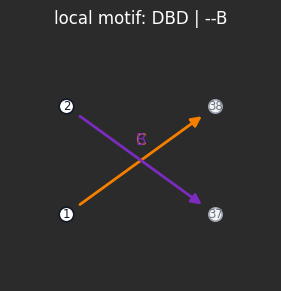

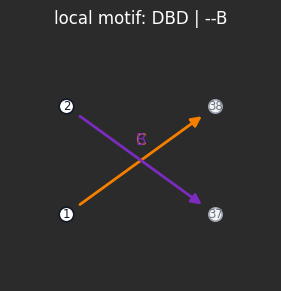

In [6]:
import sys
from pathlib import Path

GENERIC_ROOT = Path(r"E:\paper11\generic")
if str(GENERIC_ROOT) not in sys.path:
    sys.path.insert(0, str(GENERIC_ROOT))

from src.motif_generator.module.drawing import draw_motif_support

# motif = {
#     "w": 3,
#     "h": 3,
#     "support": [
#         (0, 0, "D"),
#         (0, 1, "B"),
#         (0, 2, "D"),
#         (1, 2, "B"),
#     ],
# }



motif = {
    "w": 2,
    "h": 2,
    "support": [
        (0, 0, "C"),
          (0, 1, "B"),

    ],
}

OUT_DIR = Path(r"E:\paper11\data\linshi\notebook_draw_local_motif")
OUT_PATH = OUT_DIR / "motif_000056_DBD_xxB_local.png"

fig, ax = draw_motif_support(
    motif,
    out_path=OUT_PATH,
    row_pitch=36,
    title="local motif: DBD | --B",
)
print("wrote:", OUT_PATH)
fig


## 8. 从 YAML 读取 motif，并铺满到 P x N

正式使用时，用户层不需要在 Python 代码里手写 motif。建议把 `w/h/support/grid/tiling/viewer` 放到 YAML 里，代码只读 YAML 并生成结果。

这里使用：

`E:\paper11\generic\src\motif_generator\examples\configs\motif_000056_support.yaml`

输出包括 `placed_edges.csv`、`placements.csv`、`meta.json`。


In [1]:
import sys
import importlib
from pathlib import Path

GENERIC_ROOT = Path(r"E:\paper11\generic")
if str(GENERIC_ROOT) not in sys.path:
    sys.path.insert(0, str(GENERIC_ROOT))

from src.motif_generator.module.config_io import load_motif_support_yaml, load_yaml_dict
from src.motif_generator.module.drawing import draw_motif_support
import src.motif_generator.module.tiling as tiling_module

# Reload avoids using an old function cached by a running notebook kernel.
tiling_module = importlib.reload(tiling_module)
tile_motif_on_grid = tiling_module.tile_motif_on_grid
write_tiled_motif_outputs = tiling_module.write_tiled_motif_outputs

CONFIG_PATH = GENERIC_ROOT / "src" / "motif_generator" / "examples" / "configs" / "motif_000056_support.yaml"
OUT_DIR = Path(r"E:\paper11\data\linshi\notebook_tile_motif_000056_from_yaml")

raw_config = load_yaml_dict(CONFIG_PATH)
grid = raw_config.get("grid", {})
tiling = raw_config.get("tiling", {})
motif_support = load_motif_support_yaml(CONFIG_PATH)

result = tile_motif_on_grid(
    p=int(grid.get("p", 18)),
    n=int(grid.get("n", 36)),
    motif=motif_support,
    horizontal_step=tiling.get("horizontal_step"),
    allow_vertical_overlap=bool(tiling.get("allow_vertical_overlap", True)),
    allow_clipped_right=bool(tiling.get("allow_clipped_right", True)),
)
write_tiled_motif_outputs(result, OUT_DIR)
draw_motif_support(
    motif_support,
    out_path=OUT_DIR / "local_motif_preview.png",
    row_pitch=int(grid.get("n", 36)),
    title=motif_support.name,
)

print("config:", CONFIG_PATH)
print("motif:", motif_support.name)
print("grid:", grid)
print("tiling:", tiling)
print("accepted placements:", result.accepted_count)
print("rejected placements:", result.rejected_count)
print("placed edges:", result.edge_count)
print("out_dir:", OUT_DIR)

motif support: [(0, 0, 'D'), (0, 1, 'B'), (0, 2, 'D'), (1, 2, 'B')]
motif label: {(0,0,D), (0,1,B), (0,2,D), (1,2,B)}
accepted placements: 170
rejected placements: 136
placed edges: 450
out_dir: E:\paper11\data\linshi\notebook_tile_motif_000056


## 9. 用共享 2D viewer 查看 YAML motif 铺满后的全局形态

这个单元会读取同一个 YAML，先生成铺满后的 `edge_table`，再用共享 `SatelliteTopology2DViewer` 打开 2D 交互窗口。

注意：viewer 只显示已经准备好的 `edge_table`，不在 GUI 里做 motif 转换。

在 Jupyter 中需要启用 Qt 事件循环，代码里已经包含：

```python
get_ipython().run_line_magic("gui", "qt5")
```


In [3]:
import sys
import importlib
from pathlib import Path

try:
    get_ipython().run_line_magic("gui", "qt5")
except NameError:
    pass

GENERIC_ROOT = Path(r"E:\paper11\generic")
if str(GENERIC_ROOT) not in sys.path:
    sys.path.insert(0, str(GENERIC_ROOT))

from PyQt5 import QtWidgets
from src.config.viewer_config import G60_CONFIG
from src.motif_generator.module.config_io import load_motif_support_yaml, load_yaml_dict
import src.motif_generator.module.tiling as tiling_module
from src.motif_generator.module.viewer_adapter import tiled_result_to_edge_table
from src.satellite_topology_viewer.module.base_viewer import SatelliteTopology2DViewer

tiling_module = importlib.reload(tiling_module)
tile_motif_on_grid = tiling_module.tile_motif_on_grid

CONFIG_PATH = GENERIC_ROOT / "src" / "motif_generator" / "examples" / "configs" / "motif_000056_support.yaml"
raw_config = load_yaml_dict(CONFIG_PATH)
tiling = raw_config.get("tiling", {})
viewer_raw = raw_config.get("viewer", {})
motif_support = load_motif_support_yaml(CONFIG_PATH)

result = tile_motif_on_grid(
    p=G60_CONFIG.P,
    n=G60_CONFIG.N,
    motif=motif_support,
    horizontal_step=tiling.get("horizontal_step"),
    allow_vertical_overlap=bool(tiling.get("allow_vertical_overlap", True)),
    allow_clipped_right=bool(tiling.get("allow_clipped_right", True)),
)
edge_table = tiled_result_to_edge_table(result)

app = QtWidgets.QApplication.instance() or QtWidgets.QApplication([])
viewer = SatelliteTopology2DViewer(
    G60_CONFIG,
    steps=[int(viewer_raw.get("step", 1))],
    edge_table=edge_table,
    window_title=f"G60 YAML motif 2D: {result.motif_label}",
    group_data={},
    show_groups=False,
)
viewer.edge_width = float(viewer_raw.get("edge_width", 0.045))
viewer.edge_alpha = int(viewer_raw.get("edge_alpha", 190))
viewer.width_slider.setValue(int(max(8, min(50, round(viewer.edge_width * 1000)))))
viewer.alpha_slider.setValue(int(max(25, min(190, viewer.edge_alpha))))
viewer.resize(int(viewer_raw.get("width", 1200)), int(viewer_raw.get("height", 760)))
viewer.update_step(0)
viewer.show()

_viewer_refs = globals().setdefault("_viewer_refs", [])
_viewer_refs.append(viewer)

print("2D viewer shown")
print("config:", CONFIG_PATH)
print("motif:", motif_support.name)
print("accepted placements:", result.accepted_count)
print("edges:", edge_table.num_edges)
viewer

2D viewer shown
motif label: {(0,0,D), (0,1,B), (0,2,D), (1,2,B)}
accepted placements: 170
edges: 450


## 10. 和平均最短延迟实验衔接

motif generation 只负责产生 motif library CSV。

后续计算 China-Europe 平均最短传播延迟时，把 CSV 传给：

```text
E:\paper11\generic\paper1notebook\codex2\build_g60_selected_motifs_shortest_delay_parallel.py
```

最重要参数是：

```text
--selected-motif-csv  你的 CSV 路径
```

In [ ]:
from pathlib import Path

CSV_PATH = Path(r"E:\paper11\data\linshi\motif_w4h3_canonical_from_notebook\canonical_w4_h3.csv")
OUT_DIR = Path(r"E:\paper11\data\linshi\g60_w4h3_from_notebook_china_europe_t0_86160_stride60")
SCRIPT = Path(r"E:\paper11\generic\paper1notebook\codex2\build_g60_selected_motifs_shortest_delay_parallel.py")
PYTHON = Path(r"C:\ProgramData\miniconda3\envs\paper11\python.exe")

print("示例命令：")
print(f"& '{PYTHON}' -u '{SCRIPT}' --selected-motif-csv '{CSV_PATH}' --out-dir '{OUT_DIR}' --start 0 --end 86160 --stride 60 --source-group 2 --target-group 3 --max-workers 32 --chunk-size 60")

## 11. 常见问题

### 为什么 w=4,h=3 不是 1156？

因为 1156 是 maximal 数量。实验用 library 还做了 primitive 过滤和平移/图等价去重：

```text
maximal = 1156
primitive matrix = 1148
canonical = 706
```

### CSV 里的 motif 怎么看？

例如：

```text
DBD | --B
```

表示两列 planning columns：

```text
第 0 列：D, B, D
第 1 列：-, -, B
```

### edges 里的 1-73 是真实全网边吗？

不是。它是局部 box 的代表编号，方便人读。真正全网边表需要经过 tiling 后生成。